# 실험 1: M 초기화 분산 해결 (M Lottery Fix)

AISO(Domain, N=12) mean=0.6041 ± 0.0250. 분산 주원인: **M 행렬 품질**.

이전 실패: 워밍업 다양성 기반 M 선택 → 다양성 ≠ 올바른 지역 커버리지.

## 두 가지 접근

**Part 2 — 방문 분포 누적 앙상블**: K개의 다른 M으로 독립 실행 후 방문 빈도 합산.
선택 기준 없음, 나쁜 M이 좋은 M으로 희석됨.

**Part 3 — EDA 기반 커스텀 M**: 이상치 도메인 피처의 상관관계 구조로 M 초기화.
- 상관이 높은 피처 쌍 → 에이전트 반발 (중복 탐색 방지)
- 상관이 낮거나 음수 → 에이전트 인력 (상호 보완적 탐색)

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler as MMS, StandardScaler
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE = r'c:\Users\kevin\OneDrive\Desktop\AISO\Elliptic Bitcoin\elliptic_bitcoin_dataset'

print('Elliptic 데이터 로딩...')
feat_df = pd.read_csv(f'{BASE}/elliptic_txs_features.csv', header=None)
cls_df  = pd.read_csv(f'{BASE}/elliptic_txs_classes.csv')
edge_df = pd.read_csv(f'{BASE}/elliptic_txs_edgelist.csv')
feat_df.columns = ['txId'] + [f'f{i}' for i in range(1, 167)]
feat_df['timestep'] = feat_df['f1'].astype(int)
df = feat_df.merge(cls_df, on='txId')
labeled = df[df['class'] != 'unknown'].copy().reset_index(drop=True)
labeled['y'] = (labeled['class'] == '1').astype(int)
feat_cols = [f'f{i}' for i in range(1, 167)]
X_all = labeled[feat_cols].values.astype(float)
y_all = labeled["y"].values
ts_all = labeled["timestep"].values
N_NODES = len(labeled)
txid_to_idx = {txid: i for i, txid in enumerate(labeled["txId"].values)}

e_s = edge_df['txId1'].map(txid_to_idx)
e_d = edge_df['txId2'].map(txid_to_idx)
valid = e_s.notna() & e_d.notna()
s_arr = e_s[valid].astype(int).values
d_arr = e_d[valid].astype(int).values
mask  = (s_arr < N_NODES) & (d_arr < N_NODES)
ei_np2 = np.stack([s_arr[mask], d_arr[mask]])

SPLIT_T = 34
train_mask = ts_all <= SPLIT_T
test_mask  = ts_all >  SPLIT_T
train_illicit_idx = np.where(train_mask & (y_all == 1))[0]
train_licit_idx   = np.where(train_mask & (y_all == 0))[0]
N_LICIT = 10000; N_SEEN = 1000
X_scaled = StandardScaler().fit_transform(X_all)
print(f'로딩 완료: {N_NODES:,} 노드')

c:\Users\kevin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Elliptic 데이터 로딩...
로딩 완료: 46,564 노드


In [2]:
neigh_count = np.bincount(ei_np2[0], minlength=N_NODES).astype(float)
node_degree = neigh_count.copy()
illicit_labels = y_all.astype(float)
illicit_neigh_sum = np.zeros(N_NODES)
np.add.at(illicit_neigh_sum, ei_np2[0], illicit_labels[ei_np2[1]])
illicit_neigh_ratio = illicit_neigh_sum / np.maximum(neigh_count, 1)
neigh2_illicit = np.zeros(N_NODES)
np.add.at(neigh2_illicit, ei_np2[0], illicit_neigh_ratio[ei_np2[1]])
neigh2_illicit /= np.maximum(neigh_count, 1)
ts_illicit_rate_map = {t: y_all[ts_all==t].mean() for t in np.unique(ts_all)}
node_ts_illicit_rate = np.array([ts_illicit_rate_map[t] for t in ts_all])
local_feat = X_scaled[:, 1:94]; agg_feat = X_scaled[:, 94:166]
local_mean = local_feat.mean(1); local_std = local_feat.std(1); local_max = local_feat.max(1)
agg_mean   = agg_feat.mean(1);   agg_std   = agg_feat.std(1);   agg_max   = agg_feat.max(1)
ts_norm = (ts_all - ts_all.min()) / max(ts_all.max() - ts_all.min(), 1)
hub_fraud = node_degree * illicit_neigh_ratio
domain_feat_raw = np.stack([node_degree, illicit_neigh_ratio, neigh2_illicit,
    node_ts_illicit_rate, local_mean, local_std, local_max,
    agg_mean, agg_std, agg_max, ts_norm, hub_fraud], axis=1)
domain_feat_norm = MMS().fit_transform(domain_feat_raw)
X_anom_domain = domain_feat_norm[train_illicit_idx]
N_DOM = X_anom_domain.shape[1]

FEAT_NAMES = ['degree', 'illicit_neigh', 'neigh2_illicit', 'ts_illicit',
              'local_mean', 'local_std', 'local_max',
              'agg_mean', 'agg_std', 'agg_max', 'ts_norm', 'hub_fraud']
print(f'도메인 피처: {N_DOM}차원 x {len(train_illicit_idx):,} 이상 노드')

도메인 피처: 12차원 x 3,462 이상 노드


In [3]:
class GCN(torch.nn.Module):
    def __init__(self, in_ch, hidden=64, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_ch, hidden); self.conv2 = GCNConv(hidden, hidden)
        self.lin = torch.nn.Linear(hidden, 2); self.drop = dropout
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, self.drop, self.training)
        return self.lin(F.relu(self.conv2(x, edge_index)))

_LOOKUP = np.full(N_NODES, -1, dtype=np.int32)

def evaluate_gnn(sampled_anom_idx, seed=42):
    torch.manual_seed(seed)
    licit_idx = np.random.RandomState(seed).choice(train_licit_idx, N_LICIT, replace=False)
    train_idx = np.concatenate([licit_idx, train_illicit_idx[sampled_anom_idx]])
    _LOOKUP[:] = -1
    for loc, glob in enumerate(train_idx): _LOOKUP[glob] = loc
    sub_src = []; sub_dst = []
    for s, d in zip(ei_np2[0], ei_np2[1]):
        if _LOOKUP[s] >= 0 and _LOOKUP[d] >= 0:
            sub_src.append(_LOOKUP[s]); sub_dst.append(_LOOKUP[d])
    if not sub_src: return {'PR-AUC': 0.0}
    ei_sub = torch.tensor([sub_src, sub_dst], dtype=torch.long).to(DEVICE)
    X_tr = torch.tensor(X_scaled[train_idx], dtype=torch.float).to(DEVICE)
    y_tr = torch.tensor(y_all[train_idx], dtype=torch.long).to(DEVICE)
    model = GCN(X_tr.shape[1]).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
    w = torch.tensor([1.0, 10.0]).to(DEVICE)
    for _ in range(100):
        model.train(); opt.zero_grad()
        F.cross_entropy(model(X_tr, ei_sub), y_tr, weight=w).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        test_idx = np.where(test_mask)[0]
        X_te = torch.tensor(X_scaled[test_idx], dtype=torch.float).to(DEVICE)
        tidx_map = {g: l for l, g in enumerate(test_idx)}
        src_te = []; dst_te = []
        for s, d in zip(ei_np2[0], ei_np2[1]):
            if s in tidx_map and d in tidx_map:
                src_te.append(tidx_map[s]); dst_te.append(tidx_map[d])
        if not src_te: return {'PR-AUC': 0.0}
        ei_te = torch.tensor([src_te, dst_te], dtype=torch.long).to(DEVICE)
        probs = torch.softmax(model(X_te, ei_te), 1)[:, 1].cpu().numpy()
        y_te  = y_all[test_idx]
    return {'PR-AUC': average_precision_score(y_te, probs),
            'F1':     f1_score(y_te, (probs>0.5).astype(int), zero_division=0),
            'AUC':    roc_auc_score(y_te, probs)}

print('GCN 평가 함수 정의 완료')

GCN 평가 함수 정의 완료


In [4]:
GNN_N_AG = 20; GNN_N_IT = 80; GNN_ALPHA = 0.2; GNN_BETA = 0.08
GNN_M_LOW = -0.5; GNN_W_REPEL = 2.0; N_TYPES_DOM = 12
SEEDS_VAL = [0, 7, 42, 77, 123]
KNOWN_BASELINE = 0.6041; KNOWN_STD = 0.0250

def _norm(X):
    mn, mx = X.min(0), X.max(0)
    return (X - mn) / np.where(mx - mn > 1e-8, mx - mn, 1.0)

def _run_core(Xn, W, M, eval_seed, n_types):
    N_a = len(Xn)
    rng = np.random.RandomState(eval_seed)
    X = Xn[rng.choice(N_a, GNN_N_AG, replace=True)].copy().astype(float)
    visit = np.zeros(N_a); w_r = GNN_W_REPEL
    for t in range(GNN_N_IT):
        if t % 10 == 0:
            div = np.mean([np.linalg.norm(X[i]-X[j])
                           for i in range(GNN_N_AG) for j in range(i+1, GNN_N_AG)])
            w_r = 1.0 + 3.0 * np.exp(-div / 0.12)
        C = W @ M @ W.T; np.fill_diagonal(C, 0)
        for i in range(GNN_N_AG):
            ci = C[i].copy(); ci[i] = 0
            ta = np.argsort(ci)[-3:]; tr2 = np.argsort(ci)[:3]
            Fv = sum(ci[j]*(X[j]-X[i]) for j in ta)
            Fv += w_r * sum(ci[j]*(X[j]-X[i]) for j in tr2)
            Fv /= 6.0
            nn_idx = np.argmin(np.linalg.norm(Xn - np.clip(X[i]+GNN_ALPHA*Fv,0,1), axis=1))
            X[i] = Xn[nn_idx]; visit[nn_idx] += 1.0
            bja = ta[np.argmax(ci[ta])]
            W_new = (1-GNN_BETA)*W[i] + GNN_BETA*W[bja]; W_new /= W_new.sum()
            W[i] = W_new
    return visit

def run_aiso_single(X_a, n, eval_seed, m_seed=None, n_types=12):
    if m_seed is None: m_seed = eval_seed
    rng_m = np.random.RandomState(m_seed)
    rng_s = np.random.RandomState(eval_seed)
    Xn = _norm(X_a)
    W = rng_s.dirichlet(np.ones(n_types), GNN_N_AG)
    M = rng_m.uniform(GNN_M_LOW, GNN_W_REPEL, (n_types, n_types))
    visit = _run_core(Xn, W, M, eval_seed, n_types)
    probs = visit + 1.0; probs /= probs.sum()
    return rng_s.choice(len(Xn), n, replace=True, p=probs), visit

print('핵심 AISO 함수 정의 완료')

핵심 AISO 함수 정의 완료


M 분산 진단: eval_seed=42, m_seed 30개
  mean=0.5971  std=0.0092
  min=0.5793   max=0.6149
  range=0.0355


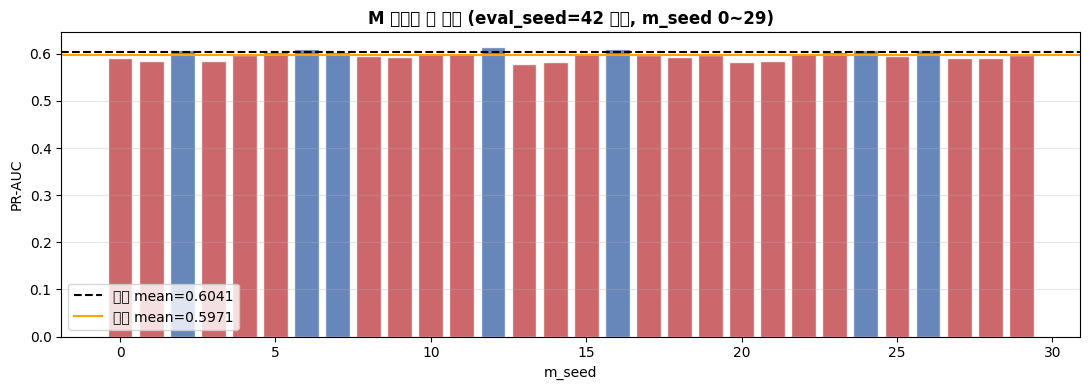

In [5]:
# Part 1: M 분산 진단 (eval_seed=42 고정, m_seed 0~29)
print('M 분산 진단: eval_seed=42, m_seed 30개')
diag_scores = []
for ms in range(30):
    idx, _ = run_aiso_single(X_anom_domain, N_SEEN, eval_seed=42, m_seed=ms)
    diag_scores.append(evaluate_gnn(idx)['PR-AUC'])
diag_scores = np.array(diag_scores)
print(f'  mean={diag_scores.mean():.4f}  std={diag_scores.std():.4f}')
print(f'  min={diag_scores.min():.4f}   max={diag_scores.max():.4f}')
print(f'  range={diag_scores.max()-diag_scores.min():.4f}')

fig, ax = plt.subplots(figsize=(11, 4))
colors = np.where(diag_scores > KNOWN_BASELINE, '#4C72B0', '#C44E52')
ax.bar(range(30), diag_scores, color=colors, alpha=0.85, edgecolor='white')
ax.axhline(KNOWN_BASELINE, color='k', ls='--', lw=1.5, label=f'기준 mean={KNOWN_BASELINE:.4f}')
ax.axhline(diag_scores.mean(), color='orange', ls='-', lw=1.5,
           label=f'이번 mean={diag_scores.mean():.4f}')
ax.set_xlabel('m_seed'); ax.set_ylabel('PR-AUC')
ax.set_title('M 초기화 운 진단 (eval_seed=42 고정, m_seed 0~29)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig('exp1_m_variance.png', bbox_inches='tight', dpi=120)
plt.show()

## Part 2: 방문 분포 누적 앙상블

K개의 서로 다른 m_seed로 독립 AISO 실행 → 방문 빈도 합산 → 합산 분포 샘플링.

eval_seed와 m_seed를 분리해서 평가 무작위성과 M 무작위성을 독립으로 유지.
`m_seed = eval_seed * 100 + k`

In [6]:
def run_ensemble(X_a, n, eval_seed, K=5, n_types=12):
    Xn = _norm(X_a); N_a = len(Xn)
    rng_s = np.random.RandomState(eval_seed)
    total_visit = np.zeros(N_a)
    for k in range(K):
        m_seed = eval_seed * 100 + k
        rng_m = np.random.RandomState(m_seed)
        W = rng_s.dirichlet(np.ones(n_types), GNN_N_AG)
        M = rng_m.uniform(GNN_M_LOW, GNN_W_REPEL, (n_types, n_types))
        total_visit += _run_core(Xn, W.copy(), M, eval_seed, n_types)
    probs = total_visit + 1.0; probs /= probs.sum()
    return rng_s.choice(N_a, n, replace=True, p=probs)

Ks = [1, 2, 3, 5, 8, 10]
ensemble_results = {}

print(f'{"K":>3} | {"mean":>7} | {"std":>7} | vs 기준')
print('-' * 40)
for K in Ks:
    scores = [evaluate_gnn(run_ensemble(X_anom_domain, N_SEEN, sd, K=K))['PR-AUC']
              for sd in SEEDS_VAL]
    m, s = np.mean(scores), np.std(scores)
    ensemble_results[K] = scores
    flag = '★' if m > KNOWN_BASELINE else ''
    print(f'  K={K:<2} | {m:.4f}  | {s:.4f}  | {m-KNOWN_BASELINE:+.4f} {flag}')
print()
print(f'  기존  |  {KNOWN_BASELINE:.4f}  |  {KNOWN_STD:.4f}  |  (기준)')

  K |    mean |     std | vs 기준
----------------------------------------
  K=1  | 0.5762  | 0.0179  | -0.0279 
  K=2  | 0.5719  | 0.0228  | -0.0322 
  K=3  | 0.5752  | 0.0223  | -0.0289 
  K=5  | 0.5854  | 0.0319  | -0.0187 
  K=8  | 0.5756  | 0.0540  | -0.0285 
  K=10 | 0.5781  | 0.0285  | -0.0260 

  기존  |  0.6041  |  0.0250  |  (기준)


## Part 3: EDA 기반 커스텀 M

이상치 도메인 피처의 **상관관계 구조**로 M을 초기화.

$$M_{kl} = -
ho_{kl} \cdot w_{	ext{repel}}$$

- $
ho_{kl}$ 높음(두 피처 상관) → $M_{kl}$ 음수 → 해당 타입 에이전트 반발 → 중복 탐색 방지
- $
ho_{kl}$ 낮거나 음수 → $M_{kl}$ 양수 → 에이전트 인력 → 상호보완적 탐색

**변형 2**: 랜덤 perturbation 추가 (`M_eda + noise * scale`)로 순수 상관 행렬의 과도한 제약 완화

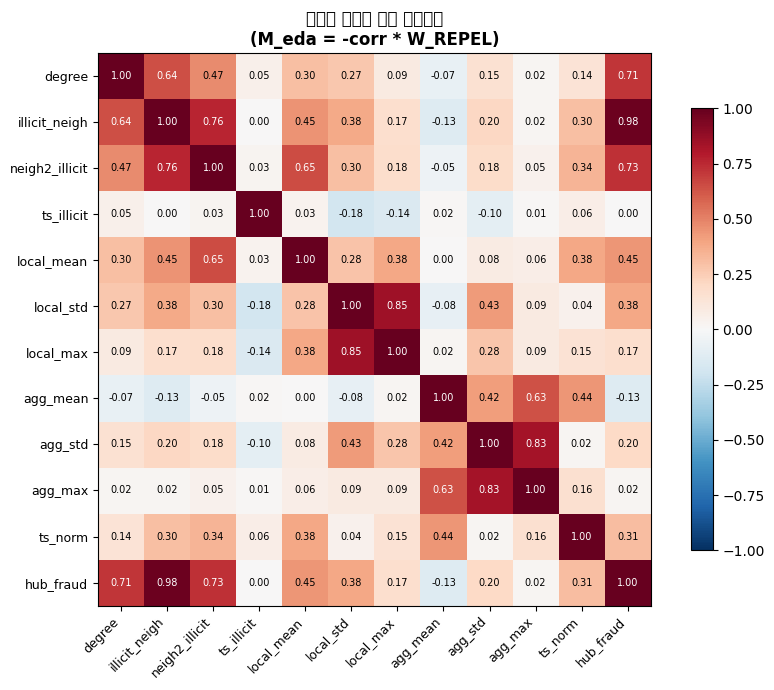

높은 상관 쌍 (|r|>0.7):
  degree <-> hub_fraud: r=0.711
  illicit_neigh <-> neigh2_illicit: r=0.760
  illicit_neigh <-> hub_fraud: r=0.979
  neigh2_illicit <-> hub_fraud: r=0.733
  local_std <-> local_max: r=0.851
  agg_std <-> agg_max: r=0.833


In [7]:
# EDA: 이상치 도메인 피처 상관관계 시각화
corr_matrix = np.corrcoef(X_anom_domain.T)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(N_DOM)); ax.set_xticklabels(FEAT_NAMES, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(N_DOM)); ax.set_yticklabels(FEAT_NAMES, fontsize=9)
for i in range(N_DOM):
    for j in range(N_DOM):
        ax.text(j, i, f'{corr_matrix[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='black' if abs(corr_matrix[i,j]) < 0.6 else 'white')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('이상치 도메인 피처 상관관계\n(M_eda = -corr * W_REPEL)', fontweight='bold')
plt.tight_layout(); plt.savefig('exp1_feat_corr.png', bbox_inches='tight', dpi=120)
plt.show()

print('높은 상관 쌍 (|r|>0.7):')
for i in range(N_DOM):
    for j in range(i+1, N_DOM):
        if abs(corr_matrix[i,j]) > 0.7:
            print(f'  {FEAT_NAMES[i]} <-> {FEAT_NAMES[j]}: r={corr_matrix[i,j]:.3f}')

In [8]:
def run_eda_m(X_a, n, eval_seed, noise_scale=0.0, n_types=12):
    rng_s = np.random.RandomState(eval_seed)
    Xn = _norm(X_a); N_a = len(Xn)
    W = rng_s.dirichlet(np.ones(n_types), GNN_N_AG)
    # EDA M: 상관 구조 반전
    M = -corr_matrix * GNN_W_REPEL
    if noise_scale > 0:
        rng_n = np.random.RandomState(eval_seed + 9999)
        M = M + rng_n.uniform(-noise_scale, noise_scale, M.shape)
    visit = _run_core(Xn, W.copy(), M, eval_seed, n_types)
    probs = visit + 1.0; probs /= probs.sum()
    return rng_s.choice(N_a, n, replace=True, p=probs)

# 순수 EDA M
eda_configs = [
    ('EDA M (순수)',        0.0),
    ('EDA M + noise 0.3',  0.3),
    ('EDA M + noise 0.5',  0.5),
    ('EDA M + noise 1.0',  1.0),
    ('EDA M + noise 1.5',  1.5),
]

eda_results = {}
print(f'{"방법":<25} {"mean":>7} {"std":>7} vs 기준')
print('-' * 50)
for label, ns in eda_configs:
    scores = [evaluate_gnn(run_eda_m(X_anom_domain, N_SEEN, sd, noise_scale=ns))['PR-AUC']
              for sd in SEEDS_VAL]
    m, s = np.mean(scores), np.std(scores)
    eda_results[label] = scores
    flag = '★' if m > KNOWN_BASELINE else ''
    print(f'  {label:<23} {m:.4f}  {s:.4f}  {m-KNOWN_BASELINE:+.4f} {flag}')
print()
print(f'  {"기존 AISO(Dom,N=12)":<23} {KNOWN_BASELINE:.4f}  {KNOWN_STD:.4f}  (기준)')

방법                           mean     std vs 기준
--------------------------------------------------
  EDA M (순수)              0.5821  0.0169  -0.0220 
  EDA M + noise 0.3       0.5728  0.0230  -0.0313 
  EDA M + noise 0.5       0.5778  0.0214  -0.0263 
  EDA M + noise 1.0       0.5768  0.0247  -0.0273 
  EDA M + noise 1.5       0.5786  0.0223  -0.0255 

  기존 AISO(Dom,N=12)       0.6041  0.0250  (기준)


In [9]:
# EDA M + 앙상블 조합
def run_eda_ensemble(X_a, n, eval_seed, K=5, noise_scale=0.5, n_types=12):
    Xn = _norm(X_a); N_a = len(Xn)
    rng_s = np.random.RandomState(eval_seed)
    total_visit = np.zeros(N_a)
    for k in range(K):
        rng_n = np.random.RandomState(eval_seed * 100 + k)
        W = rng_s.dirichlet(np.ones(n_types), GNN_N_AG)
        M = -corr_matrix * GNN_W_REPEL
        M = M + rng_n.uniform(-noise_scale, noise_scale, M.shape)
        total_visit += _run_core(Xn, W.copy(), M, eval_seed, n_types)
    probs = total_visit + 1.0; probs /= probs.sum()
    return rng_s.choice(N_a, n, replace=True, p=probs)

combo_configs = [
    ('EDA+Ens K=3 ns=0.5', 3, 0.5),
    ('EDA+Ens K=5 ns=0.5', 5, 0.5),
    ('EDA+Ens K=5 ns=1.0', 5, 1.0),
    ('EDA+Ens K=8 ns=0.5', 8, 0.5),
]

combo_results = {}
print('EDA M + 앙상블 조합...')
print(f'{"방법":<25} {"mean":>7} {"std":>7} vs 기준')
print('-' * 50)
for label, K, ns in combo_configs:
    scores = [evaluate_gnn(run_eda_ensemble(X_anom_domain, N_SEEN, sd, K=K, noise_scale=ns))['PR-AUC']
              for sd in SEEDS_VAL]
    m, s = np.mean(scores), np.std(scores)
    combo_results[label] = scores
    flag = '★' if m > KNOWN_BASELINE else ''
    print(f'  {label:<23} {m:.4f}  {s:.4f}  {m-KNOWN_BASELINE:+.4f} {flag}')

EDA M + 앙상블 조합...
방법                           mean     std vs 기준
--------------------------------------------------
  EDA+Ens K=3 ns=0.5      0.5847  0.0217  -0.0194 
  EDA+Ens K=5 ns=0.5      0.5753  0.0473  -0.0288 
  EDA+Ens K=5 ns=1.0      0.5809  0.0395  -0.0232 
  EDA+Ens K=8 ns=0.5      0.5866  0.0285  -0.0175 


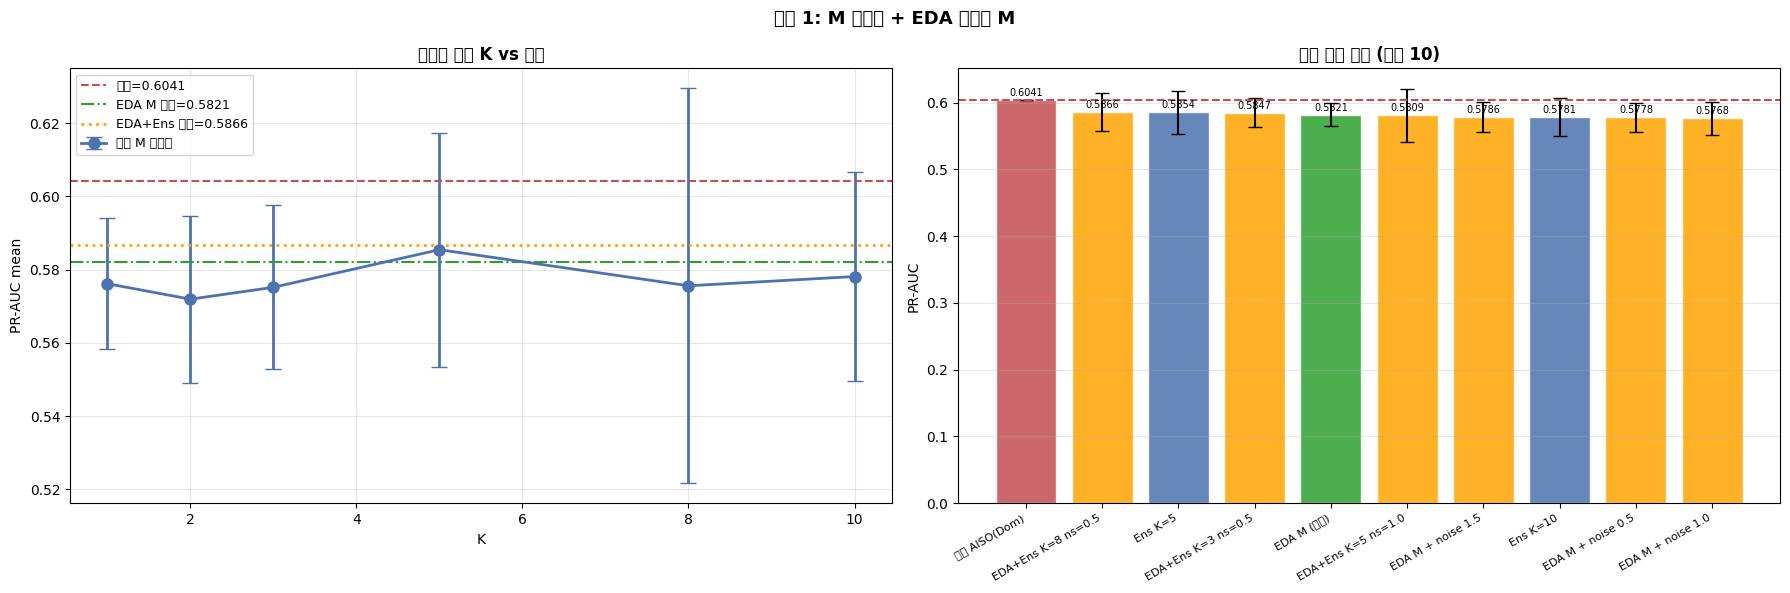

In [10]:
# 전체 결과 종합 시각화
all_results = {
    '기존 AISO(Dom)': [KNOWN_BASELINE] * 5,
}
for K in Ks:
    all_results[f'Ens K={K}'] = ensemble_results[K]
for label, _ in eda_configs:
    all_results[label] = eda_results[label]
for label, _, _ in combo_configs:
    all_results[label] = combo_results[label]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 왼쪽: 앙상블 K vs mean/std
ax = axes[0]
Ks_list = list(ensemble_results.keys())
means_e = [np.mean(ensemble_results[k]) for k in Ks_list]
stds_e  = [np.std(ensemble_results[k])  for k in Ks_list]
ax.errorbar(Ks_list, means_e, yerr=stds_e, fmt='o-', color='#4C72B0',
            lw=2, ms=8, capsize=6, label='랜덤 M 앙상블')
ax.axhline(KNOWN_BASELINE, color='#C44E52', ls='--', lw=1.5, label=f'기존={KNOWN_BASELINE:.4f}')

best_eda_label = max(eda_results, key=lambda k: np.mean(eda_results[k]))
best_eda_m = np.mean(eda_results[best_eda_label])
ax.axhline(best_eda_m, color='#2ca02c', ls='-.', lw=1.5,
           label=f'EDA M 최고={best_eda_m:.4f}')
best_combo_label = max(combo_results, key=lambda k: np.mean(combo_results[k]))
best_combo_m = np.mean(combo_results[best_combo_label])
ax.axhline(best_combo_m, color='orange', ls=':', lw=2,
           label=f'EDA+Ens 최고={best_combo_m:.4f}')
ax.set_xlabel('K'); ax.set_ylabel('PR-AUC mean')
ax.set_title('앙상블 크기 K vs 성능', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# 오른쪽: 전체 방법 바 차트 (상위 방법만)
ax = axes[1]
top_methods = sorted(all_results.items(), key=lambda x: np.mean(x[1]), reverse=True)[:10]
lbls  = [k for k,_ in top_methods]
ms    = [np.mean(v) for _,v in top_methods]
ss    = [np.std(v)  for _,v in top_methods]
clrs  = ['#C44E52' if '기존' in l else
         '#4C72B0' if 'Ens' in l and 'EDA' not in l else
         '#2ca02c' if 'EDA' in l and '+' not in l else
         'orange' for l in lbls]
bars = ax.bar(range(len(lbls)), ms, yerr=ss, capsize=5,
              color=clrs, alpha=0.85, edgecolor='white')
ax.axhline(KNOWN_BASELINE, color='#C44E52', ls='--', lw=1.5)
ax.set_xticks(range(len(lbls))); ax.set_xticklabels(lbls, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('PR-AUC'); ax.set_title('전체 방법 비교 (상위 10)', fontweight='bold')
ax.grid(alpha=0.3, axis='y')
for bar, m in zip(bars, ms):
    ax.text(bar.get_x()+bar.get_width()/2, m+0.003, f'{m:.4f}',
            ha='center', va='bottom', fontsize=7)

plt.suptitle('실험 1: M 앙상블 + EDA 커스텀 M', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.savefig('exp1_final.png', bbox_inches='tight', dpi=120)
plt.show()

In [11]:
print('=' * 65)
print('실험 1: 최종 결과 요약')
print('=' * 65)
all_combined = {**{'기존 AISO': [KNOWN_BASELINE]*5},
                **{f'Ens K={k}': v for k,v in ensemble_results.items()},
                **eda_results, **combo_results}
sorted_all = sorted(all_combined.items(), key=lambda x: np.mean(x[1]), reverse=True)
print(f'{"방법":<28} {"mean":>7} {"std":>7}  vs 기준')
print('-' * 65)
for label, scores in sorted_all:
    m, s = np.mean(scores), np.std(scores)
    flag = '★' if m > KNOWN_BASELINE and label != '기존 AISO' else ''
    print(f'  {label:<26} {m:.4f}  {s:.4f}  {m-KNOWN_BASELINE:+.4f} {flag}')
print('=' * 65)

실험 1: 최종 결과 요약
방법                              mean     std  vs 기준
-----------------------------------------------------------------
  기존 AISO                    0.6041  0.0000  +0.0000 
  EDA+Ens K=8 ns=0.5         0.5866  0.0285  -0.0175 
  Ens K=5                    0.5854  0.0319  -0.0187 
  EDA+Ens K=3 ns=0.5         0.5847  0.0217  -0.0194 
  EDA M (순수)                 0.5821  0.0169  -0.0220 
  EDA+Ens K=5 ns=1.0         0.5809  0.0395  -0.0232 
  EDA M + noise 1.5          0.5786  0.0223  -0.0255 
  Ens K=10                   0.5781  0.0285  -0.0260 
  EDA M + noise 0.5          0.5778  0.0214  -0.0263 
  EDA M + noise 1.0          0.5768  0.0247  -0.0273 
  Ens K=1                    0.5762  0.0179  -0.0279 
  Ens K=8                    0.5756  0.0540  -0.0285 
  EDA+Ens K=5 ns=0.5         0.5753  0.0473  -0.0288 
  Ens K=3                    0.5752  0.0223  -0.0289 
  EDA M + noise 0.3          0.5728  0.0230  -0.0313 
  Ens K=2                    0.5719  0.0228  -0.0322 
